In [118]:
from dotenv import load_dotenv
load_dotenv()

True

In [119]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

In [120]:
memory = InMemorySaver()

In [121]:
class EmailState(BaseModel):
    query: str =""
    draft : str =""
    feedback : str = ""
    final_draft : str = ""

In [122]:
llm = ChatGroq(model = "openai/gpt-oss-120b")


In [123]:
def drafting (state: EmailState) -> EmailState :
    if state.feedback:
        res = llm.invoke(f"""
                         You have generated draft for this query {state.draft}
                         but we received a feedback {state.feedback}
                         Rewrite the email by incorporating the feedback.

                         Return only the revised email.
                         
                         """)
    else: 
        res = llm.invoke(f"draft a mail for this topic {state.query}")
        
    state.draft = res.content
    return state
        
        
 

In [124]:
def human_feedback ( state : EmailState) -> EmailState:
    feedback = interrupt({
        "draft_email" : state.draft,
        "question" : "Do you want to continue or re-write the mail?"
    })
    fb = (feedback or "").strip().lower()
    if fb in ("approved","yes","ok","done","finish","hogya"):
        state.feedback =""
        return state
    else :
        state.feedback = feedback
        return state

In [125]:
def final_draft(state:EmailState)->EmailState:
    
        state.final_draft = state.draft
        return state

In [126]:
def conditional_routing(state: EmailState)->Literal["draft","final"]:
   if state.feedback:
     return "draft"
   return "final"

In [127]:
graph = StateGraph(EmailState)
graph.add_node("draft",drafting)
graph.add_node("feedback",human_feedback)
graph.add_node("final",final_draft)

graph.add_edge(START,"draft")
graph.add_edge("draft","feedback")
graph.add_conditional_edges("feedback", conditional_routing)
graph.add_edge("final",END)

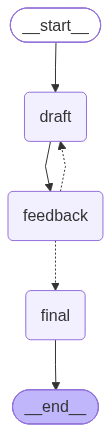

In [128]:
graph = graph.compile(checkpointer=memory)
graph

In [129]:
config = {"configurable":{"thread_id":"1"}}

In [130]:
res = graph.invoke({"query":"write a mail to ask a friends health"},
                   config)

In [131]:
print(res['draft'])

**Subject:** Just checking in – how are you feeling?  

---

Hi [Friend’s Name],

I hope this note finds you well. I’ve been thinking about you lately and wanted to check in to see how you’re feeling.

How have you been doing health‑wise? I know you’ve had a few things going on, and I just wanted to let you know I’m here if you need anything—whether it’s a quick chat, a grocery run, or just a distraction with a funny meme.  

If you feel up to it, I’d love to hear how you’re getting on and what you might need right now. No pressure at all—just let me know whenever you’re comfortable.

Take care of yourself, and remember you’re not alone in this. Looking forward to hearing from you soon.

Warm wishes,

[Your Name]  
[Your Phone (optional)]  
[Your Email (optional)]  


In [132]:
feedback = "in here,add the friend name as sakshi and sender name as Neemisha"
res = graph.invoke(Command(resume =feedback), config = config)

In [135]:
print(res["draft"])

Hi Sakshi,

I hope this note finds you well. I’ve been thinking about you lately and wanted to check in to see how you’re feeling.

How have you been doing health‑wise? I know you’ve had a few things going on, and I just wanted to let you know I’m here if you need anything—whether it’s a quick chat, a grocery run, or just a distraction with a funny meme.

If you feel up to it, I’d love to hear how you’re getting on and what you might need right now. No pressure at all—just let me know whenever you’re comfortable.

Take care of yourself, and remember you’re not alone in this. Looking forward to hearing from you soon.

Warm wishes,

Neemisha  
[Your Phone (optional)]  
[Your Email (optional)]
